In [309]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.feature_selection import RFE

In [17]:
# Reading CSV File and Loading into DataFrame
file_path = "/Users/joudisinjab/Desktop/german_credit.csv"
german_credit = pd.read_csv(file_path)

# Exploring first 6 rows of dataset
german_credit.head()

,Creditability,Account Balance,Duration of Credit (month),Payment Status of Previous Credit,Purpose,Credit Amount,Value Savings/Stocks,Length of current employment,Instalment per cent,Sex & Marital Status,...,Duration in Current address,Most valuable available asset,Age (years),Concurrent Credits,Type of apartment,No of Credits at this Bank,Occupation,No of dependents,Telephone,Foreign Worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2


In [57]:
# Descriptive statistics of data set
german_credit.describe()

,Creditability,Account Balance,Duration of Credit (month),Payment Status of Previous Credit,Purpose,Credit Amount,Value Savings/Stocks,Length of current employment,Instalment per cent,Sex & Marital Status,...,Duration in Current address,Most valuable available asset,Age (years),Concurrent Credits,Type of apartment,No of Credits at this Bank,Occupation,No of dependents,Telephone,Foreign Worker
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,...,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.700000,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,...,2.845000,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.155000,1.404000,1.037000
std,0.458487,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,...,1.103718,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856
min,0.000000,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,...,2.000000,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
50%,1.000000,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,...,3.000000,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
75%,1.000000,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,...,4.000000,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,1.000000,2.000000,1.000000
max,1.000000,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,...,4.000000,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000


In [69]:
#Exploring data information and types
print(german_credit.info())
print(f"\nThere are {german_credit.shape[0]} rows and {german_credit.shape[1]} columns")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Creditability                      1000 non-null   int64
 1   Account Balance                    1000 non-null   int64
 2   Duration of Credit (month)         1000 non-null   int64
 3   Payment Status of Previous Credit  1000 non-null   int64
 4   Purpose                            1000 non-null   int64
 5   Credit Amount                      1000 non-null   int64
 6   Value Savings/Stocks               1000 non-null   int64
 7   Length of current employment       1000 non-null   int64
 8   Instalment per cent                1000 non-null   int64
 9   Sex & Marital Status               1000 non-null   int64
 10  Guarantors                         1000 non-null   int64
 11  Duration in Current address        1000 non-null   int64
 12  Most valuable availab

In [61]:
# Checking for duplicated data 
duplicates = german_credit.duplicated()
print(f"There are {duplicates.sum()} duplicated rows in the dataset\n")

#Confirming there is no null values
missing_values = german_credit.isna()
print(f"{missing_values.sum()} \n\nThere are no missing values in the dataset")

There are 0 duplicated rows in the dataset

Creditability                        0
Account Balance                      0
Duration of Credit (month)           0
Payment Status of Previous Credit    0
Purpose                              0
Credit Amount                        0
Value Savings/Stocks                 0
Length of current employment         0
Instalment per cent                  0
Sex & Marital Status                 0
Guarantors                           0
Duration in Current address          0
Most valuable available asset        0
Age (years)                          0
Concurrent Credits                   0
Type of apartment                    0
No of Credits at this Bank           0
Occupation                           0
No of dependents                     0
Telephone                            0
Foreign Worker                       0
dtype: int64 

There are no missing values in the dataset


In [289]:
# Changing data types of dataset 
german_credit['Account Balance'] = pd.Categorical(german_credit['Account Balance'], categories = [1, 2, 3, 4], ordered = True)
german_credit['Payment Status of Previous Credit'] = pd.Categorical(german_credit['Payment Status of Previous Credit'], categories = [1, 2, 3, 4], ordered = True)
german_credit['Purpose'] = pd.Categorical(german_credit['Purpose'], categories = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], ordered = False)
german_credit['Value Savings/Stocks'] = pd.Categorical(german_credit['Value Savings/Stocks'], categories = [1, 2, 3, 4, 5], ordered = True)
german_credit['Length of current employment'] = pd.Categorical(german_credit['Length of current employment'], categories = [1, 2, 3, 4, 5], ordered = True)
german_credit['Sex & Marital Status'] = pd.Categorical(german_credit['Sex & Marital Status'], categories = [1, 2, 3, 4, 5], ordered = False)
german_credit['Guarantors'] = pd.Categorical(german_credit['Guarantors'], categories = [1, 2, 3], ordered = False)
german_credit['Duration in Current address'] = pd.Categorical(german_credit['Duration in Current address'], categories = [1, 2, 3, 4], ordered = True)
german_credit['Most valuable available asset'] = pd.Categorical(german_credit['Most valuable available asset'], categories = [1, 2, 3, 4], ordered = True)
german_credit['Concurrent Credits'] = pd.Categorical(german_credit['Concurrent Credits'], categories = [1, 2, 3], ordered = False)
german_credit['Type of apartment'] = pd.Categorical(german_credit['Type of apartment'], categories = [1, 2, 3], ordered = False)
german_credit['Occupation'] = pd.Categorical(german_credit['Occupation'], categories = [1, 2, 3, 4], ordered = False)
german_credit['Foreign Worker'] = german_credit['Foreign Worker'].astype(bool)
german_credit['Telephone'] = german_credit['Telephone'].astype(bool)
german_credit['Creditability'] = german_credit['Creditability'].astype(bool)

print(f"Updated data types after conversion:\n\n{german_credit.dtypes}")


Updated data types after conversion:

Creditability                            bool
Account Balance                      category
Duration of Credit (month)              int64
Payment Status of Previous Credit    category
Purpose                              category
Credit Amount                           int64
Value Savings/Stocks                 category
Length of current employment         category
Instalment per cent                     int64
Sex & Marital Status                 category
Guarantors                           category
Duration in Current address          category
Most valuable available asset        category
Age (years)                             int64
Concurrent Credits                   category
Type of apartment                    category
No of Credits at this Bank              int64
Occupation                           category
No of dependents                        int64
Telephone                                bool
Foreign Worker                           b

<function matplotlib.pyplot.show(close=None, block=None)>

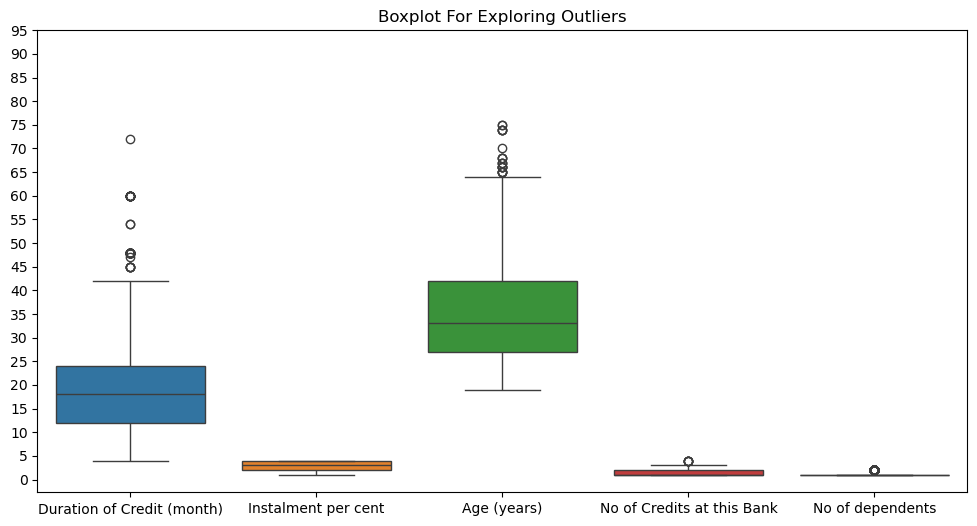

In [115]:
# Exploring outliers for numeric variables 
numeric_attributes = ['Duration of Credit (month)', 'Instalment per cent', 'Age (years)', 'No of Credits at this Bank', 'No of dependents'] 

plt.figure(figsize=(12,6))
sns.boxplot(data = german_credit[numeric_attributes])
plt.title('Boxplot For Exploring Outliers')
plt.yticks(range(0,100,5))
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

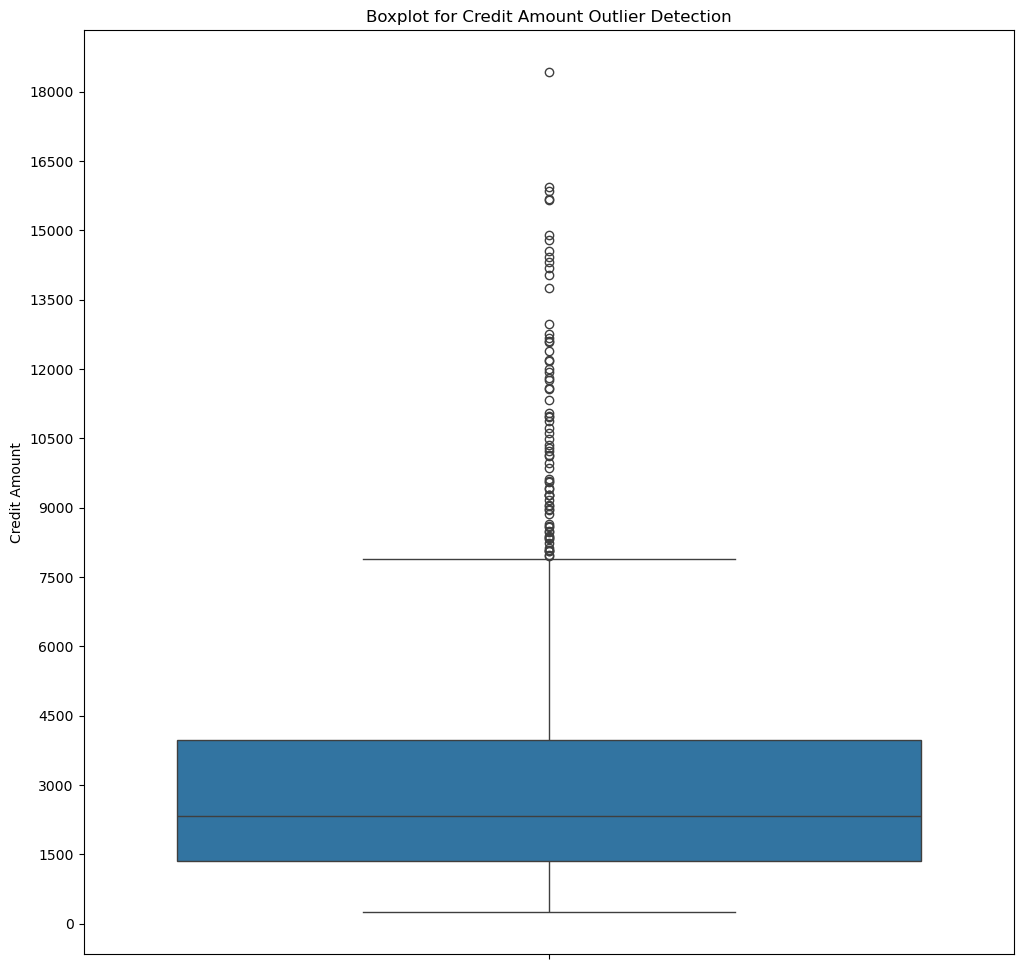

In [133]:
plt.figure(figsize= (12,12))
sns.boxplot(german_credit['Credit Amount'])
plt.title('Boxplot for Credit Amount Outlier Detection')
plt.yticks(range(0, 19500, 1500))
plt.show

In [181]:
# Calculate correlations of numerical features with the target variable
numerical_columns = ['Duration of Credit (month)', 'Account Balance', 'Instalment per cent', 'Age (years)', 'No of Credits at this Bank', 'No of dependents']
corr_matrix = german_credit[numerical_columns + ['Creditability']].corr()

# Display the correlation with target variable
corr_matrix


,Duration of Credit (month),Account Balance,Instalment per cent,Age (years),No of Credits at this Bank,No of dependents,Creditability
Duration of Credit (month),1.000000,-0.072013,0.074749,-0.037550,-0.011284,-0.023834,-0.214927
Account Balance,-0.072013,1.000000,-0.005280,0.058631,0.076005,-0.014145,0.350847
Instalment per cent,0.074749,-0.005280,1.000000,0.057271,0.021669,-0.071207,-0.072404
Age (years),-0.037550,0.058631,0.057271,1.000000,0.150718,0.118589,0.091272
No of Credits at this Bank,-0.011284,0.076005,0.021669,0.150718,1.000000,0.109667,0.045732
No of dependents,-0.023834,-0.014145,-0.071207,0.118589,0.109667,1.000000,0.003015
Creditability,-0.214927,0.350847,-0.072404,0.091272,0.045732,0.003015,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

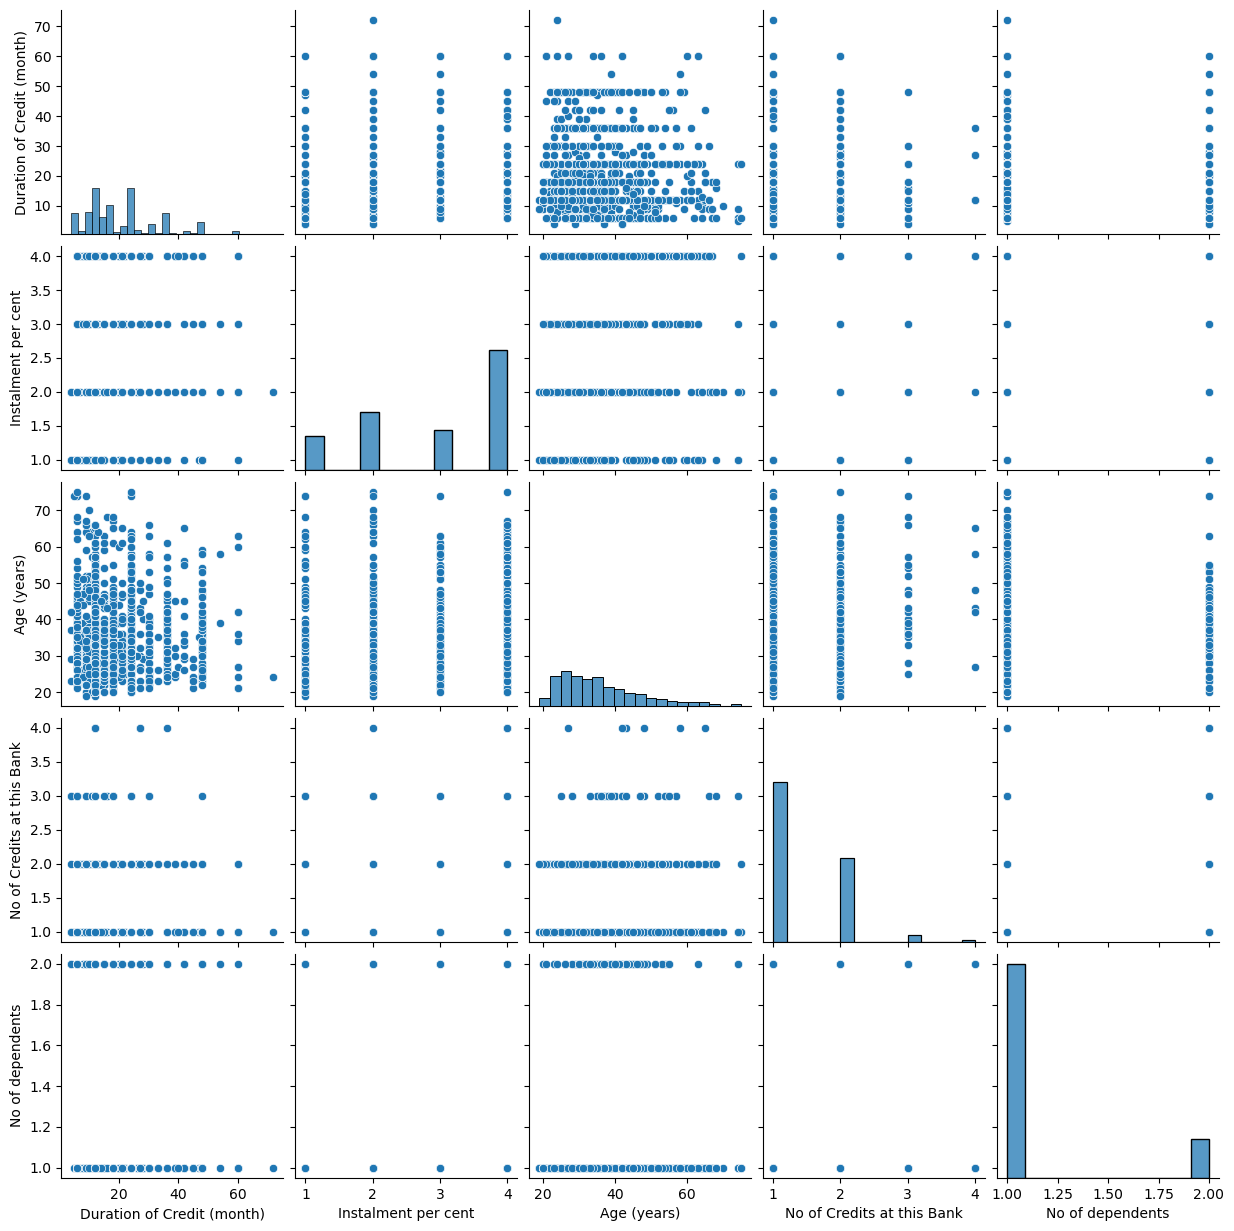

In [297]:
# Numerical Columns Scatter plot matrix 
sns.pairplot(german_credit[numerical_columns])
plt.show

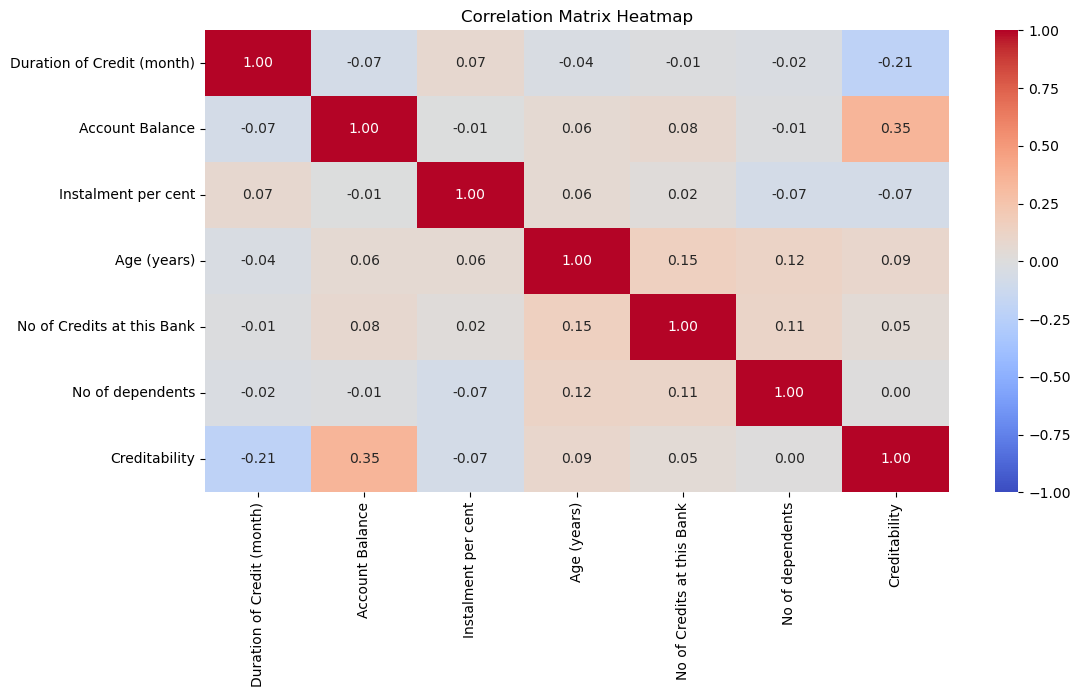

In [187]:
# Visiualizing Numeric Attributes Correlation Matrix 
plt.figure(figsize=(12, 6))  
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, center=0)

# Add a title to the heatmap
plt.title('Correlation Matrix Heatmap')

# Show the plot
plt.show()

In [235]:
cat_columns = ['Account Balance', 'Payment Status of Previous Credit', 'Purpose', 'Value Savings/Stocks', 'Length of current employment', 'Sex & Marital Status',
               'Guarantors', 'Duration in Current address', 'Most valuable available asset', 'Concurrent Credits', 'Type of apartment', 'Occupation', 'Telephone', 'Foreign Worker']

significant_features = []

for cat in cat_columns:
    contingency_table = pd.crosstab(german_credit[cat], german_credit['Creditability'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-Square test result for {cat}: p-value = {p:.4e}")
    if p < 0.05:
        significant_features.append(cat)
        print(f"  -> Significant association with target (p-value = {p:.4e}).\n")
    else:
        print(f"  -> No significant association (p-value = {p:.4e}).\n")

if significant_features:
    print("\nSignificant categorical variables:")
    print(", ".join(significant_features))
else:
    print("\nNo significant associations found between categorical variables and the target variable.")
  

Chi-Square test result for Account Balance: p-value = 1.2189e-26
  -> Significant association with target (p-value = 1.2189e-26).

Chi-Square test result for Payment Status of Previous Credit: p-value = 4.3171e-09
  -> Significant association with target (p-value = 4.3171e-09).

Chi-Square test result for Purpose: p-value = 1.4277e-03
  -> Significant association with target (p-value = 1.4277e-03).

Chi-Square test result for Value Savings/Stocks: p-value = 2.7612e-07
  -> Significant association with target (p-value = 2.7612e-07).

Chi-Square test result for Length of current employment: p-value = 1.0455e-03
  -> Significant association with target (p-value = 1.0455e-03).

Chi-Square test result for Sex & Marital Status: p-value = 2.2238e-02
  -> Significant association with target (p-value = 2.2238e-02).

Chi-Square test result for Guarantors: p-value = 3.6056e-02
  -> Significant association with target (p-value = 3.6056e-02).

Chi-Square test result for Duration in Current address:

Creditability
True     700
False    300
Name: count, dtype: int64


/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_98755/230323231.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imbalance.index, y=imbalance.values, palette=['skyblue', 'salmon'])


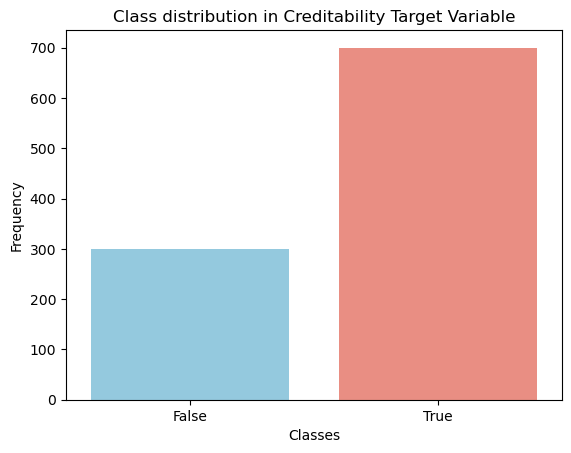

In [287]:
# Checking for imbalance in dataset
imbalance = german_credit['Creditability'].value_counts()
print(imbalance)

# Visualizing imbalance 
sns.barplot(x=imbalance.index, y=imbalance.values, palette=['skyblue', 'salmon'])
plt.title('Class distribution in Creditability Target Variable')
plt.xlabel('Classes')
plt.ylabel('Frequency')
plt.show()

In [322]:
# Creating an array with all feature names for first decision tree model
features = ['Account Balance', 'Duration of Credit (month)',
       'Payment Status of Previous Credit', 'Purpose', 'Credit Amount',
       'Value Savings/Stocks', 'Length of current employment',
       'Instalment per cent', 'Sex & Marital Status', 'Guarantors',
       'Duration in Current address', 'Most valuable available asset',
       'Age (years)', 'Concurrent Credits', 'Type of apartment',
       'No of Credits at this Bank', 'Occupation', 'No of dependents',
       'Telephone', 'Foreign Worker']

# Splitting DF 
X = german_credit[features] 
y = german_credit['Creditability']

# Splitting train and test subsets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

dtree = DecisionTreeClassifier()
dtree = dtree.fit(X_train, y_train)

y_pred_test = dtree.predict(X_test)

# Determining model prediction metrics 

# Calculate evaluation metrics
test_accuracy = accuracy_score(y_test, y_pred_test)
sensitivity = recall_score(y_test, y_pred_test, pos_label=1)
specificity = recall_score(y_test, y_pred_test, pos_label=0)
conf_matrix = confusion_matrix(y_test, y_pred_test)

# Output the results
print("Confusion Matrix:\n", conf_matrix)
print("Test Accuracy:", test_accuracy)
print("Sensitivity (Recall for Good Credit):", sensitivity)
print("Specificity (Recall for Bad Credit):", specificity)

# Extract TP, FP, TN, FN from the confusion matrix
tn, fp, fn, tp = conf_matrix.ravel()
print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

# Additional interpretation of the results
print("\nInterpretation:")
print(f"Accuracy indicates how often the model is correct: {test_accuracy:.2f}")
print(f"Sensitivity (Recall) is the ability of the model to find all the positive Good Credit instances: {sensitivity:.2f}")
print(f"Specificity is the ability of the model to identify negative Bad credit instances: {specificity:.2f}")

Confusion Matrix:
 [[ 43  49]
 [ 40 168]]
Test Accuracy: 0.7033333333333334
Sensitivity (Recall for Good Credit): 0.8076923076923077
Specificity (Recall for Bad Credit): 0.4673913043478261
True Negatives (TN): 43
False Positives (FP): 49
False Negatives (FN): 40
True Positives (TP): 168

Interpretation:
Accuracy indicates how often the model is correct: 0.70
Sensitivity (Recall) is the ability of the model to find all the positive Good Credit instances: 0.81
Specificity is the ability of the model to identify negative Bad credit instances: 0.47


In [328]:
# Decision tree model with significant feature selection 

sig_features = ['Account Balance', 'Duration of Credit (month)',
       'Payment Status of Previous Credit', 'Purpose', 'Credit Amount',
       'Length of current employment', 'Instalment per cent',
       'Duration in Current address', 'Most valuable available asset',
       'Age (years)']

# Splitting DF 
X2 = german_credit[sig_features] 
y2 = german_credit['Creditability']

# Splitting train and test subsets 
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=42)

dtree = DecisionTreeClassifier()
dtree = dtree.fit(X2_train, y2_train)

y2_pred_test = dtree.predict(X2_test)

# Determining model prediction metrics 

# Calculate evaluation metrics
test_accuracy2 = accuracy_score(y2_test, y2_pred_test)
sensitivity2 = recall_score(y2_test, y2_pred_test, pos_label=1)
specificity2 = recall_score(y2_test, y2_pred_test, pos_label=0)
conf_matrix2 = confusion_matrix(y2_test, y2_pred_test)

# Output the results
print("Confusion Matrix:\n", conf_matrix2)
print("Test Accuracy:", test_accuracy2)
print("Sensitivity (Recall for Good Credit):", sensitivity2)
print("Specificity (Recall for Bad Credit):", specificity2)

# Extract TP, FP, TN, FN from the confusion matrix
tn2, fp2, fn2, tp2 = conf_matrix2.ravel()
print("True Negatives (TN):", tn2)
print("False Positives (FP):", fp2)
print("False Negatives (FN):", fn2)
print("True Positives (TP):", tp2)

# Additional interpretation of the results
print("\nInterpretation:")
print(f"Accuracy indicates how often the model is correct: {test_accuracy2:.2f}")
print(f"Sensitivity (Recall) is the ability of the model to find all the positive Good Credit instances: {sensitivity2:.2f}")
print(f"Specificity is the ability of the model to identify negative Bad credit instances: {specificity2:.2f}")

Confusion Matrix:
 [[ 45  47]
 [ 45 163]]
Test Accuracy: 0.6933333333333334
Sensitivity (Recall for Good Credit): 0.7836538461538461
Specificity (Recall for Bad Credit): 0.4891304347826087
True Negatives (TN): 45
False Positives (FP): 47
False Negatives (FN): 45
True Positives (TP): 163

Interpretation:
Accuracy indicates how often the model is correct: 0.69
Sensitivity (Recall) is the ability of the model to find all the positive Good Credit instances: 0.78
Specificity is the ability of the model to identify negative Bad credit instances: 0.49


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)


In [326]:
dtree = DecisionTreeClassifier(random_state=42)
rfe = RFE(dtree, n_features_to_select=10)
rfe.fit(X, y)

selected_features = X.columns[rfe.support_]
print("Selected Features via RFE:", selected_features)

Selected Features via RFE: Index(['Account Balance', 'Duration of Credit (month)',
       'Payment Status of Previous Credit', 'Purpose', 'Credit Amount',
       'Length of current employment', 'Instalment per cent',
       'Duration in Current address', 'Most valuable available asset',
       'Age (years)'],
      dtype='object')


In [330]:
scores = cross_val_score(all_features_model, X2, y2, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy:", scores.mean())

Cross-Validation Accuracy: 0.668


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype